# PROCESS 2 — Forward Chaining (PL-FC-ENTAILS)

Implements **PL-FC-ENTAILS** with:
- `Clause` — stores premise as a **set** (O(1) membership check)
- `Problem` — maintains an **inverted index** symbol→clauses (O(1) agenda propagation)
- `pl_fc_entails` — uses `collections.deque` for O(1) front-pop
- `Solution` — clean OOP wrapper with formatted display

## Import libraries


In [19]:
from __future__ import annotations
from collections import deque
from graphviz import Digraph
from IPython.display import Image, display

## Introduce about graphviz

clause : -a -b c

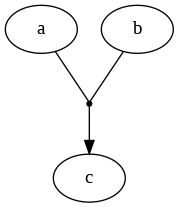

In [20]:
dot = Digraph()

dot.node('a', label = 'a')
dot.node('b', label = 'b')
dot.node('c')
dot.node('dot', shape = 'point')

dot.edge('a', 'dot', arrowhead = 'none')
dot.edge('b', 'dot', arrowhead = 'none')
dot.edge('dot', 'c')

dot.render('negated_implication_1', format = 'png', view = True)

Image(filename='negated_implication_1.png')

clause : -b -c -d e

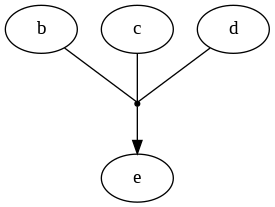

In [21]:
dot = Digraph()

dot.node('b', label = 'b')
dot.node('c', label = 'c')
dot.node('d', label = 'd')
dot.node('e')
dot.node('dot', shape = 'point')

dot.edge('b', 'dot', arrowhead = 'none')
dot.edge('c', 'dot', arrowhead = 'none')
dot.edge('d', 'dot', arrowhead = 'none')
dot.edge('dot', 'e')

dot.render('negated_implication_2', format = 'png', view = True)

Image(filename='negated_implication_2.png')

## Defining Clause class

In [22]:
class Clause:
    """A propositional definite clause: premise1 ∧ ... ∧ premiseN ⇒ conclusion.

    Attributes
    ----------
    premise    : frozenset[str]  — symbols that must all be true (O(1) lookup)
    conclusion : str             — symbol inferred when all premises are satisfied
    """

    __slots__ = ('premise', 'conclusion')

    def __init__(self, premise: list[str], conclusion: str) -> None:
        self.premise    = frozenset(premise)   # O(1) membership test
        self.conclusion = conclusion

    # ------------------------------------------------------------------ display
    def __str__(self) -> str:
        if not self.premise:
            return f'\u22a4 \u21d2 {self.conclusion}'          # ⊤ ⇒ c
        body = ' \u2227 '.join(sorted(self.premise))           # a ∧ b ∧ ...
        return f'{body} \u21d2 {self.conclusion}'

    def __repr__(self) -> str:
        return self.__str__()

## Defining Problem class

In [23]:
class Problem:
    """Knowledge base + inverted index for efficient forward chaining."""

    def __init__(self, kb_file: str | None = None) -> None:
        self.clauses: list[Clause] = []
        self.symbols: set[str]    = set()
        # inverted index: symbol -> indices of clauses whose premise contains it
        self._idx: dict[str, list[int]] = {}

        if kb_file:
            self.load_from_file(kb_file)

    # ----------------------------------------------------------------- mutators
    def add_clause(self, premise: list[str], conclusion: str) -> Clause:
        clause = Clause(premise, conclusion)
        idx    = len(self.clauses)
        self.clauses.append(clause)

        # update symbol set & inverted index
        self.symbols.add(conclusion)
        for sym in clause.premise:
            self.symbols.add(sym)
            self._idx.setdefault(sym, []).append(idx)

        return clause

    def load_from_file(self, filename: str) -> None:
        """Parse definite-clause file: negated tokens are premises, bare token is conclusion."""
        with open(filename, 'r') as fh:
            for raw in fh:
                parts = raw.strip().split()
                if not parts:
                    continue
                premises   = [p[1:] for p in parts if p.startswith('-')]
                conclusion = next((p for p in parts if not p.startswith('-')), None)
                if conclusion is not None:
                    self.add_clause(premises, conclusion)

    # ----------------------------------------------------------------- queries
    def get_kb(self) -> list[Clause]:
        return self.clauses

    def clauses_with_premise(self, symbol: str) -> list[int]:
        """Return indices of clauses whose premise contains *symbol* (O(1) lookup)."""
        return self._idx.get(symbol, [])

    # --------------------------------------------------------------- visualize
    def visualize(self, output_file: str = 'logic_graph') -> Image:
        """Render KB as a directed graph with dot-node join for multi-premise clauses."""
        dot = Digraph()
        dot.attr(rankdir='TB', size='10,10', dpi='150')
        dot.node_attr.update(fontname='Helvetica', fontsize='12')

        added_nodes: set[str] = set()

        def ensure_node(name: str, **attrs) -> None:
            if name not in added_nodes:
                dot.node(name, **attrs)
                added_nodes.add(name)

        for i, clause in enumerate(self.clauses):
            ensure_node(clause.conclusion, shape='ellipse')

            if len(clause.premise) > 1:
                hub = f'__hub_{i}__'
                dot.node(hub, shape='point', width='0.15')
                for sym in sorted(clause.premise):
                    ensure_node(sym, shape='ellipse')
                    dot.edge(sym, hub, arrowhead='none')
                dot.edge(hub, clause.conclusion)

            elif len(clause.premise) == 1:
                sym = next(iter(clause.premise))
                ensure_node(sym, shape='ellipse')
                dot.edge(sym, clause.conclusion)

            else:  # fact — no premises
                # redraw as box to indicate it is a known fact
                dot.node(clause.conclusion, shape='box',
                         style='filled', fillcolor='lightyellow')

        dot.render(output_file, format='png', cleanup=True, view=False)
        return Image(filename=f'{output_file}.png')

## Defining Algorithm

In [24]:
def pl_fc_entails(problem: Problem, query: str) -> tuple[bool, dict]:
    """PL-FC-ENTAILS as per AIMA (Russell & Norvig).

    Returns
    -------
    (result, trace)
        result : bool  — True iff KB ⊨ query
        trace  : dict  — inference steps for display
    """
    kb = problem.get_kb()

    # count[i] = number of unsatisfied premises remaining in clause i
    count: dict[int, int] = {i: len(c.premise) for i, c in enumerate(kb)}

    # inferred[s] is True once s has been processed
    inferred: dict[str, bool] = {s: False for s in problem.symbols}

    # seed agenda with facts (zero-premise clauses) — O(|KB|)
    agenda: deque[str] = deque(
        c.conclusion for c in kb if not c.premise
    )

    trace: dict = {'steps': [], 'inferred_symbols': [], 'result': False}
    step = 1

    while agenda:                          # O(|Symbols|) iterations total
        p = agenda.popleft()               # O(1)  ← was O(n) with list.pop(0)

        if p == query:
            trace['steps'].append(f'Step {step}: Found query \'{query}\' in agenda ✓')
            trace['result'] = True
            return True, trace

        if not inferred.get(p, False):
            trace['steps'].append(f'Step {step}: Processing symbol \'{p}\'')
            trace['inferred_symbols'].append(p)
            inferred[p] = True
            step += 1

            # Only visit clauses that contain p in their premise  ← O(clauses with p)
            for i in problem.clauses_with_premise(p):   # was O(|KB|)
                count[i] -= 1
                clause = kb[i]
                trace['steps'].append(
                    f'    decrement count[{clause}] → {count[i]}'
                )
                if count[i] == 0:
                    trace['steps'].append(
                        f'    all premises satisfied → add \'{clause.conclusion}\' to agenda'
                    )
                    agenda.append(clause.conclusion)

    trace['result'] = False
    return False, trace

## Defining Solution class

In [25]:
class Solution:
    """High-level interface: load KB → visualize → query → print trace."""

    def __init__(self, kb_file: str | None = None) -> None:
        self.problem = Problem(kb_file)
        self._result: bool | None = None
        self._trace:  dict | None = None

    # ------------------------------------------------------------------ chain
    def load_knowledge_base(self, kb_file: str) -> 'Solution':
        self.problem = Problem(kb_file)
        return self

    def add_clause(self, premise: list[str], conclusion: str) -> 'Solution':
        self.problem.add_clause(premise, conclusion)
        return self

    # ------------------------------------------------------------------ query
    def query(self, symbol: str) -> bool:
        self._result, self._trace = pl_fc_entails(self.problem, symbol)
        return self._result

    # ---------------------------------------------------------------- display
    def visualize(self, output_file: str = 'logic_graph') -> Image:
        return self.problem.visualize(output_file)

    def print_trace(self) -> None:
        if self._trace is None:
            print('No trace available. Run query() first.')
            return

        sep = '-' * 60
        result_str = 'TRUE' if self._trace['result'] else 'FALSE'
        print(sep)
        print(f'Query result : {result_str}')
        print(sep)
        print('Inference trace')
        print(sep)
        for step in self._trace['steps']:
            print(step)
        print(sep)
        syms = ', '.join(self._trace['inferred_symbols']) or '(none)'
        print(f'Inferred order : {syms}')
        print(sep)

## Load KB & Visualize

Knowledge Base graph:


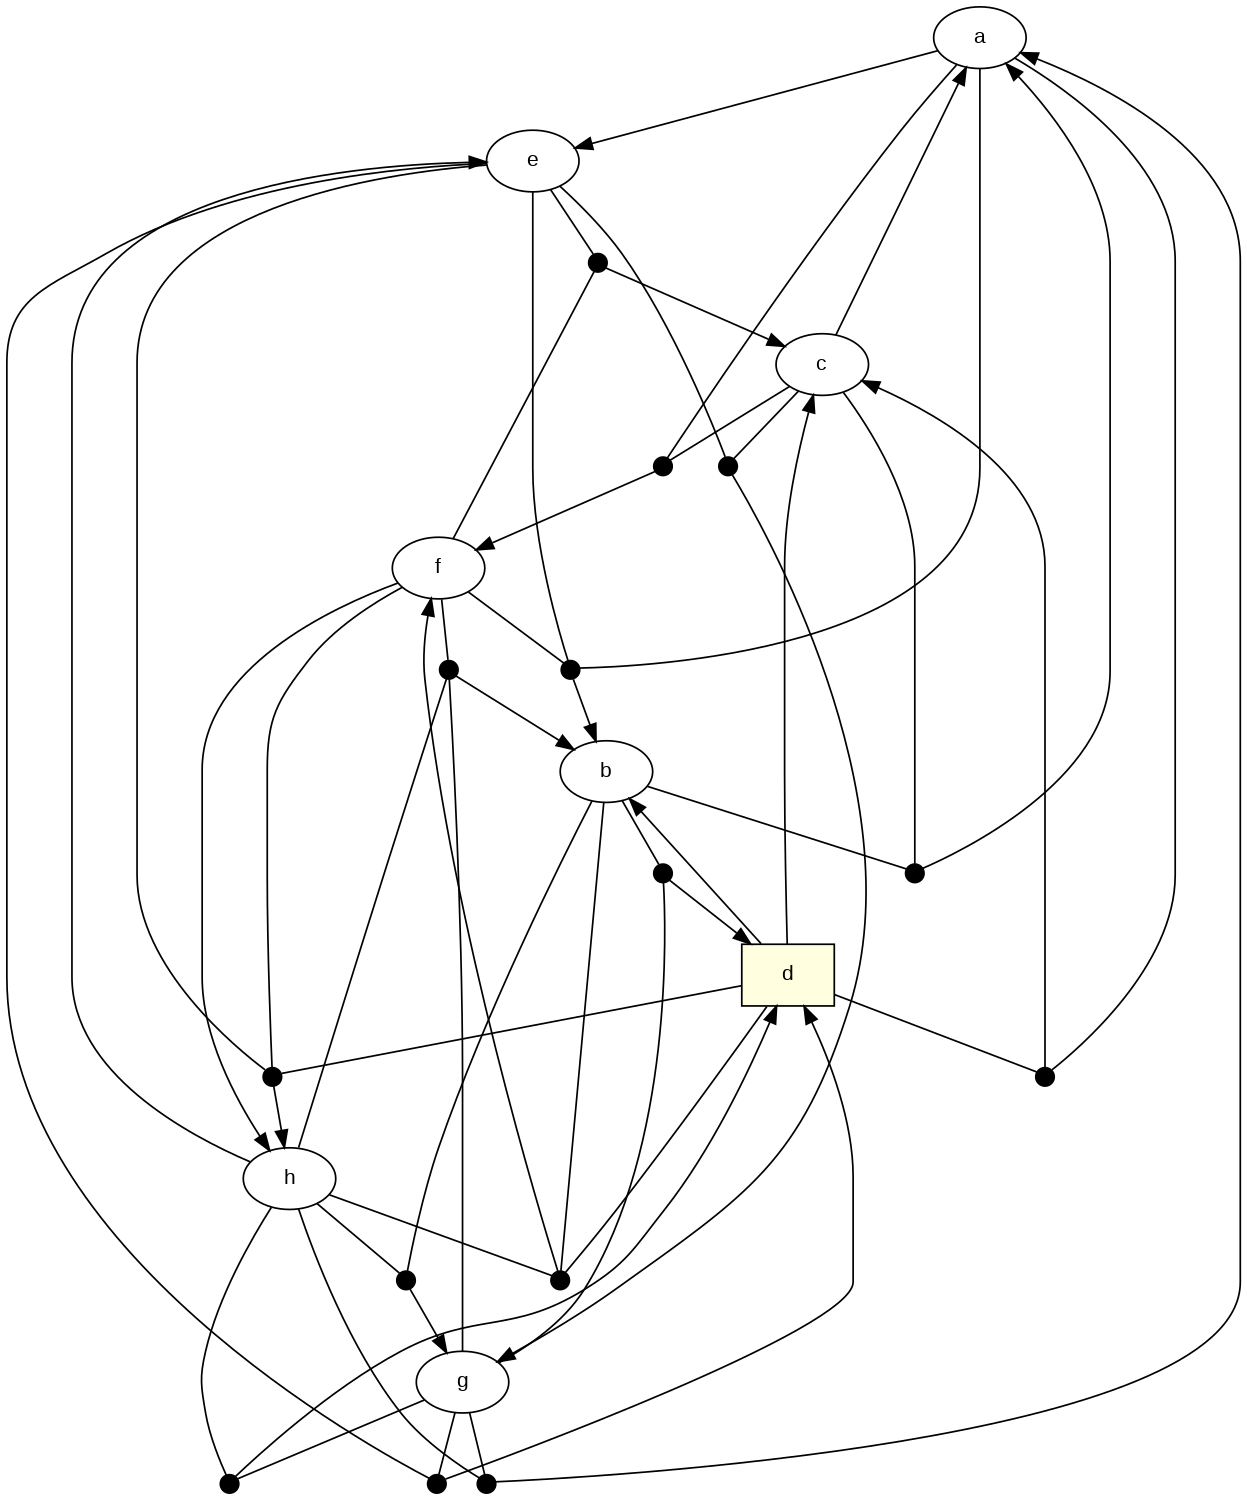


✓ Graph rendered. Now run the next cell to enter your query.


In [26]:
# ── Step 1: load knowledge base & draw graph ─────────────────────────────────
solution = Solution('data.txt')

print('Knowledge Base graph:')
display(solution.visualize())
print('\n✓ Graph rendered. Now run the next cell to enter your query.')

## Query

In [27]:
# ── Step 2: interactive query (separate cell so graph never blocks input) ─────
while True:
    q = input('Enter a single symbol to query (e.g. a-h): ').strip()
    if len(q) == 1 and q.isalpha():
        break
    print('Please enter exactly one alphabetic character.')

print(f"\nQuery : '{q}'")
solution.query(q)
solution.print_trace()

Enter a single symbol to query (e.g. a-h): e

Query : 'e'
------------------------------------------------------------
Query result : TRUE
------------------------------------------------------------
Inference trace
------------------------------------------------------------
Step 1: Processing symbol 'd'
    decrement count[d ⇒ b] → 0
    all premises satisfied → add 'b' to agenda
    decrement count[b ∧ d ∧ h ⇒ f] → 2
    decrement count[d ⇒ c] → 0
    all premises satisfied → add 'c' to agenda
    decrement count[d ∧ e ∧ f ⇒ h] → 2
    decrement count[a ∧ d ⇒ c] → 1
Step 2: Processing symbol 'b'
    decrement count[b ∧ c ⇒ a] → 1
    decrement count[b ∧ d ∧ h ⇒ f] → 1
    decrement count[b ∧ g ⇒ d] → 1
    decrement count[b ∧ h ⇒ g] → 1
Step 3: Processing symbol 'c'
    decrement count[b ∧ c ⇒ a] → 0
    all premises satisfied → add 'a' to agenda
    decrement count[c ∧ e ⇒ g] → 1
    decrement count[a ∧ c ⇒ f] → 1
    decrement count[c ⇒ a] → 0
    all premises satisfied → add 'a' 